In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [9]:
def MCP_Neurons_AND(X1, X2, T):
  '''
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1(1 nd array): An array of binary values.
  X2(1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 or 0 for the particular inputs.
  '''
  assert len(X1) == len(X2)
  state_neuron = []
  for i in range(len(X1)):
    total_input = X1[i] + X2[i]
    if total_input >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron


In [10]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2 # Threshold value
# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)
# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [11]:
def MCP_Neurons_OR(X1, X2, T):
  '''
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1(1 nd array): An array of binary values.
  X2(1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 or 0 for the particular inputs.
  '''
  assert len(X1) == len(X2)
  state_neuron = []
  for i in range(len(X1)):
    total_input = X1[i] + X2[i]
    if total_input >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)
  return state_neuron

In [12]:
#Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1 # Threshold value for OR gate
# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)
# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


Question - 1: List out all the limitations of MCP - Neurons.

Ans:MCP neurons have several limitations. First, they can only work with binary values (0 and 1), so they cannot handle real or continuous data. Second, they do not learn from data because the weights and threshold must be set manually, which makes them less flexible. Another important limitation is that a single MCP neuron can only solve simple problems that are linearly separable, so it cannot handle more complex problems like XOR. Finally, all inputs are treated equally (same weight), which makes the model too simple compared to real biological neurons.


Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}

Ans: A single MCP neuron cannot solve the XOR problem because it is not linearly separable. However, this problem can be solved by combining multiple MCP neurons. The XOR function can be expressed using the rule: (X1 OR X2) AND NOT (X1 AND X2). In simple terms, the output is 1 only when exactly one of the inputs is 1, and it is 0 when both inputs are the same (either both 0 or both 1). This can also be understood using a simple condition: if the sum of the inputs is equal to 1, the output is 1; otherwise, if the sum is 0 or 2, the output is 0.


In [13]:
import pandas as pd
import numpy as np
# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AiMl/Data/mnist_0_and_1.csv") # Add the correct file path if necessary
# Extract features and labels
X = df_0_1.drop(columns=["label"]).values # 784 pixels
y = df_0_1["label"].values # Labels (0 or 1)
# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Answer the Following Question:
    Question - 1: What does the shape of X represent?

Ans:The shape of X (12665, 784) means that there are 12,665 images in the dataset, and each image has 784 features. These 784 features come from a 28 × 28 pixel image, which is flattened into a single row of numbers.


 Question - 2: What does the shape of Y represent?

 Ans:The shape of y (12665,) means there are 12,665 labels, one for each image in X. Each value in y tells us whether the image is a 0 or a 1, so it gives the correct answer for every image.

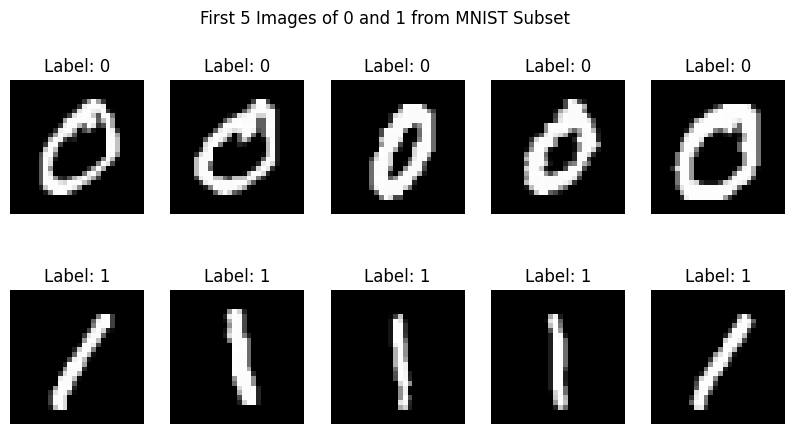

In [14]:
# Separate images for label 0 and label 1
images_0 = X[y == 0] # Get all images with label 0
images_1 = X[y == 1] # Get all images with label 1
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
if len(images_0) < 5 or len(images_1) < 5:
  print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
  for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 0")
    axes[0, i].axis("off")
# Plot digit 1
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 1")
    axes[1, i].axis("off")
plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

In [15]:
# Initialize weights and bias
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1

Question - 3: What does the weights array represent in this context?

Ans:The weights array represents the important values the model learns during training. Each of the 784 weights is connected to one pixel of the image. These weights decide how important each pixel is for predicting whether the image is a 0 or a 1. If a weight is positive, it means that pixel supports one class (like digit 1), and if it is negative, it supports the other class (like digit 0).


Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

Ans:We initialize the weights to zero so the model starts with no prior knowledge. It means the model is neutral at the beginning and learns everything from the data. During training, the perceptron will update these weights step by step based on its mistakes.For a simple model like a perceptron, starting with zero works fine because it will quickly adjust the weights. However, in more complex neural networks, starting with zero can cause problems.

In [16]:
import numpy as np
def decision_function(X, weights, bias):
  '''
  Compute the predicted labels for the input data.
  Parameters:
  -X: features(input data) as a numpy array of shape(n_samples, n_features)
  -weights: Updated weights after training
  -bias: Updated bias after training

  Returns:
  -y_pred_all:The predicted labels for the input data
  '''
  predictions = np.dot(X, weights) + bias
  y_pred_all = np.where(predictions >= 0, 1, 0)

  return y_pred_all


In [17]:
import numpy as np
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
 '''
 Train the perceptron using the Perceptron Learning Algorithm.
 Parameters:
 - X: Features (input data) as a numpy array of shape (n_samples, n_features)
 - y: Labels (true output) as a numpy array of shape (n_samples,)
 - weights: Initial weights as a numpy array of shape (n_features,)
 - bias: Initial bias value (scalar)
 - learning_rate: Learning rate for weight updates (default is 0.1)
 - epochs: Number of iterations to train the model (default is 100)
 Returns:
 - weights: Updated weights after training
 - bias: Updated bias after training
 - accuracy: Total correct prediction.
 '''
# Step 3: Perceptron Learning Algorithm
 n_samples = X.shape[0]
 for epoch in range(epochs):
  correct_predictions = 0
  for i in range(n_samples):
    linear_output = np.dot(X[i], weights) + bias
    y_pred = 1 if linear_output >= 0 else 0
    if y_pred != y[i]:
      update = learning_rate * (y[i] - y_pred)
      weights += update * X[i]
      bias += update
    else:
      correct_predictions +=1

 accuracy = correct_predictions / n_samples
 return weights, bias, accuracy









Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Ans:The line output = np.dot(X[i], weights) + bias is used to calculate the total input to the neuron. It combines all the input features (pixels) with their weights and adds the bias. This value helps the model decide whether the output should be 0 or 1 after applying the activation function.

Question -6: What happens when the prediction is wrong? How are the weights and bias updated?

Ans:When the prediction is wrong, the model corrects itself by updating the weights and bias. It adjusts them based on the error so that next time it can make a better prediction. Basically, it learns from its mistake and shifts the decision boundary in the right direction.

Question 7: Why is the final accuracy important, and what do you expect it to be?

Ans:Final accuracy is important because it shows how well the model is performing. it tells us how manu predictions are correct. For classifying digits like 0 and 1, we expect the accuracy to be very high because these digits are easy to tell apart.

In [18]:
#After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
#Evalute the model using the new function
print("The Final Accuracy is:", accuracy)

The Final Accuracy is: 1.0


In [19]:

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  for ax, idx in zip(axes.flat, misclassified_idx[:10]):
    ax.imshow(X[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
    ax.axis("off")
  plt.suptitle("Misclassified Images")
  plt.show()
else:
  print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question -8: What does misclassified idx store, and how is it used in this code?

Ans:The variable misclassified_idx stores the positions (indexes) of all the images that were predicted wrongly by the model. In this code, it is used to check if there are any mistakes. If there are, these indexes help the program pick those incorrect images and display them so we can see where the model went wrong.

Question 9: What does "All images were correctly classified!" mean?

Ans:This message means the model made no mistakes at all. It correctly predicted every image, so the accuracy is 100%. This usually happens because the dataset (digits 0 and 1) is simple and easy to separate, so the model can find a perfect boundary between them.

Task 3:Perceptron algorithm for 3 vs 5 classification


In [20]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    n_samples = X.shape[0]
    for epoch in range(epochs):
        correct_predictions = 0
        for i in range(n_samples):
            # Calculate the linear output
            linear_output = np.dot(X[i], weights) + bias
            # Step function: 1 if >= 0, else 0
            y_pred = 1 if linear_output >= 0 else 0

            # Update weights if prediction is wrong
            if y_pred != y[i]:
                update = learning_rate * (y[i] - y_pred)
                weights += update * X[i]
                bias += update
            else:
                correct_predictions += 1

    accuracy = correct_predictions / n_samples
    return weights, bias, accuracy

In [21]:

df_3_5 = pd.read_csv("/content/drive/MyDrive/AiMl/Data/mnist_3_and_5.csv")

# Extract features (X) and labels (y)
X= df_3_5.drop(columns=["label"]).values
y_raw = df_3_5["label"].values

# Change '3' to 0 and '5' to 1 so the Perceptron can process them
y = np.where(y_raw == 3, 0, 1)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


In [25]:
# Reset weights and bias for the new digit patterns
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

In [27]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)

print("The Final Accuracy for 3 vs 5 is:", accuracy)


The Final Accuracy for 3 vs 5 is: 0.9963516964611455


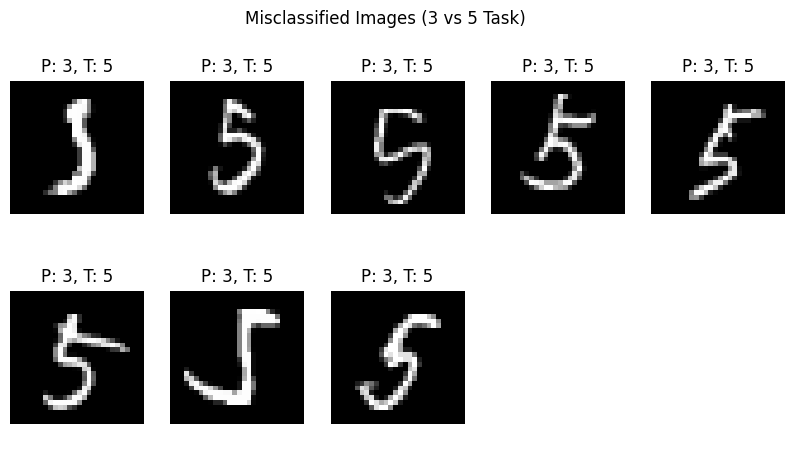

In [29]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Find indexes where predictions are wrong
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, ax in enumerate(axes.flat):
        if i < len(misclassified_idx):
            idx = misclassified_idx[i]
            ax.imshow(X[idx].reshape(28, 28), cmap="gray")

            # Convert 0/1 back to 3/5 for the title
            p_label = 5 if y_pred[idx] == 1 else 3
            t_label = 5 if y[idx] == 1 else 3

            ax.set_title(f"P: {p_label}, T: {t_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5 Task)")
    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:
The perceptron model was able to classify digits 3 and 5 with high accuracy, but it did not reach 100% like in the 0 vs 1 task. This is because 3 and 5 look quite similar, especially in their curves and shapes. When we checked the misclassified images, we saw that the model correctly identified all the 3s but made mistakes with some 5s, especially when they were written in a messy or rounded way. These results show that the data is not perfectly separable with a straight line. Overall, this proves that a single-layer perceptron works well for simple problems but struggles when the patterns are more complex and similar.
